In [2]:
import eos
import numpy as np
import pypmc
import wquantiles
import os
import json
import yaml
import sys
import scipy.stats as stats
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map

from datetime import datetime as dt
time_stamp = str(dt.now())
replaceChars = {' ': '-', ':': '-', '.': '-'}
for char in replaceChars:
    time_stamp = time_stamp.replace(char, replaceChars[char])

print("EOS installed at", eos.installation_time())

print("Notebook execution time stamp:", time_stamp)

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 7]

EOS installed at Thu Apr 13 15:01:04 2023
Notebook execution time stamp: 2023-04-15-10-09-00-330387


In [3]:
def get_gof(analysis, param_array):
    for i, param in enumerate(analysis.init_args['priors']):
        analysis.parameters.set(param['parameter'], param_array[i])
    return analysis.goodness_of_fit()

In [4]:
def get_chi2(x, mu, cov):
    return np.dot(np.transpose(np.array(x)-np.array(mu)),
                  np.dot(np.linalg.inv(np.array(cov)),
                         np.array(x)-np.array(mu)
                        )
                 )

In [5]:
def wstd(samples, weights=None):
    mean_w = np.average(samples, weights=weights)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights))

# Predict H at negative q^2

## Import F and F_T/F

In [6]:
BASE_DIRECTORY = '/home/reboud/Documents/POSTDOC/LOCALFIT/Data/BToK/BSZ/'

pmc_samples = np.load(os.path.join(BASE_DIRECTORY, 'samples', 'samples.npy'))
pmc_weights = np.load(os.path.join(BASE_DIRECTORY, 'samples', 'weights.npy'))

with open(os.path.join(BASE_DIRECTORY, 'samples', 'description.yaml'), 'r') as f:
    pmc_description = yaml.load(f.read(), Loader=yaml.SafeLoader)

In [7]:
q2_values = [-7, -5, -3, -1]
ff_obs_names = [
    "B->K::F_plus(q2)", "B->K::F_plus_T(q2)/F_plus(q2)"
    ]

params = eos.Parameters.Defaults()

ff_observables = [eos.Observable.make(
    obs_name,
    params,
    eos.Kinematics(q2=q2),
    eos.Options(**{'form-factors':'BSZ2015'})) for obs_name in ff_obs_names for q2 in q2_values]

In [8]:
parameters = [params[p['name']] for p in pmc_description['parameters']]

def compute_obs(sample):
    for p, v in zip(parameters, sample):
        p.set(v)
    return [eos.Observable.evaluate(o) for o in ff_observables]

ff_observable_samples = np.array(process_map(compute_obs, pmc_samples, max_workers=15, chunksize=5))

  0%|          | 0/23039 [00:00<?, ?it/s]

In [9]:
FToverF_mean = np.average(ff_observable_samples, axis=0, weights = pmc_weights)
FToverF_cov = np.cov(ff_observable_samples, rowvar=0, aweights = pmc_weights)

## Compute $H/F$ mean and cov

In [ ]:
# Nico's points are [Re(dC7(-7)), Im(dC7(-7)), Re(dC9(-7)), Im(dC9(-7)), Re(dC7(-5)), Im(dC7(-5)), Re(dC9(-5)), Im(dC9(-5)), Re(dC7(-3)), Im(dC7(-3)), Re(dC9(-3)), Im(dC9(-3)), Re(dC7(-1)), Im(dC7(-1)), Re(dC9(-1)), Im(dC9(-1))]
mean = np.array([
    -0.04772609914476168, -0.00183730036829226, 0.07853072280327339, 0.000908821307728336,
    -0.05001585076240161, -0.00217806915487611, 0.10502127454492018, 0.000967628009215721,
    -0.05247358603064688, -0.00262107339844842, 0.13497045338769842, 0.000989307736797652,
    -0.05510828431004989, -0.003209557376766988, 0.16960820080628938, 0.0009129068295559907
])

std = np.array([
    0.0010596498739476776, 0.00014756690755130244, 0.00223118578572523,   0.000019548637250735135,
    0.0011168640544982967, 0.0001751822271663305,  0.002585315930179785,  0.00003764960556145641,
    0.0011798751191376138, 0.0002110362377933349,  0.0030477543356543448, 0.00007096174604376924,
    0.0012479697142453085, 0.0002584159147505521, 0.0036783599048196306, 0.0001335703071316914
])

corr = np.array([
 [ 1.0000000000000000,  0.9511603226872335, -0.9995463555029989,  0.5697721665804205,
   0.9999965436962404,  0.9511031609311527, -0.9994047005986338,  0.7521212317460078,
   0.9999833786399099,  0.9510583426046816, -0.9973419642885517,  0.8304502788381475,
   0.9999599025562207,  0.9510534815399777, -0.9955033558797449,  0.8700398256340893 ],
 [ 0.9511603226872335,  0.9999999999999998, -0.9581005385849048,  0.7780061285667376,
   0.9519674867332831,  0.9999999511912714, -0.9405804878411569,  0.9088361699869112,
   0.9529231010187298,  0.9999998172004082, -0.9262406584506697,  0.9556893250611894,
   0.9538859458485561,  0.9999996940308945, -0.9176890579412043,  0.9755548437121198 ],
 [-0.9995463555029989, -0.9581005385849048,  0.9999999999999999, -0.5826076664240136,
  -0.9996031691320884, -0.9580433128720037,  0.9983884866117612, -0.7632432830540017,
  -0.9996636218054842, -0.9579974642478148,  0.995261024672565,  -0.8403603875314744,
  -0.9997167539320337, -0.9579896562574777,  0.9928008990510806, -0.87912739737703 ],
 [ 0.5697721665804205,  0.7780061285667376, -0.5826076664240136,  0.9999999999999996,
   0.5718202895234092,  0.778183689552604,  -0.541601715544514,   0.9691423514525385,
   0.5742334870477767,  0.7783398678936607, -0.5115996230462543,  0.9284084223044954,
   0.5766538560921723,  0.7784065059095654, -0.4953113399224677,  0.8968800204945587 ],
 [ 0.9999965436962404,  0.9519674867332831, -0.9996031691320884,  0.5718202895234092,
   0.9999999999999998,  0.9519108224888828, -0.9993146621834543,  0.753792627940816,
   0.9999950792604296,  0.9518664014485086, -0.9971475241441663,  0.8318783391030167,
   0.9999799787488983,  0.9518616058563749, -0.9952518221782427,  0.8713117506880746 ],
 [ 0.9511031609311527,  0.9999999511912714, -0.9580433128720037,  0.778183689552604,
   0.9519108224888828,  1.,                 -0.9405151398685017,  0.9089546742301141,
   0.9528670081103492,  0.9999999569968359, -0.9261698982336732,  0.9557735269011522,
   0.9538304103376597,  0.9999998857718226, -0.9176158647580693,  0.9756182952717098 ],
 [-0.9994047005986338, -0.9405804878411569,  0.9983884866117612, -0.541601715544514,
  -0.9993146621834543, -0.9405151398685017,  0.9999999999999998, -0.7292954740138019,
  -0.999199021992734,  -0.9404633439972587,  0.9991750587415897, -0.8110470725008943,
  -0.9990722634281763, -0.9404560837274039,  0.997995050435244,  -0.8528172549659095 ],
 [ 0.7521212317460078,  0.9088361699869112, -0.7632432830540017,  0.9691423514525385,
   0.753792627940816,   0.9089546742301141, -0.7292954740138019,  1.,
   0.7557632658520341,  0.9090590539466198, -0.7038606497212481,  0.9913502038277838,
   0.7577409757261844,  0.9091040326773625, -0.689759814065866,   0.9782241050158886 ],
 [ 0.9999833786399099,  0.9529231010187298, -0.9996636218054842,  0.5742334870477767,
   0.9999950792604296,  0.9528670081103492, -0.999199021992734,   0.7557632658520341,
   1.0000000000000004,  0.9528230383155869, -0.9969066138325713,  0.8335628544825241,
   0.9999949069743419,  0.9528183029279538, -0.9949422226839255,  0.872812521949018 ],
 [ 0.9510583426046816,  0.9999998172004082, -0.9579974642478148,  0.7783398678936607,
   0.9518664014485086,  0.9999999569968359, -0.9404633439972587,  0.9090590539466198,
   0.9528230383155869,  1.,                 -0.9261142172791077,  0.9558478405362321,
   0.9537868753452274,  0.9999999807864974, -0.9175585870350458,  0.9756744597776366 ],
 [-0.9973419642885517, -0.9262406584506697,  0.995261024672565,  -0.5115996230462543,
  -0.9971475241441663, -0.9261698982336732,  0.9991750587415897, -0.7038606497212481,
  -0.9969066138325713, -0.9261142172791077,  1.,                 -0.7887003145871461,
  -0.9966518011882668, -0.9261075552300821,  0.9997407696413877, -0.832496623342537 ],
 [ 0.8304502788381475,  0.9556893250611894, -0.8403603875314744,  0.9284084223044954,
   0.8318783391030167,  0.9557735269011522, -0.8110470725008943,  0.9913502038277838,
   0.8335628544825241,  0.9558478405362321, -0.7887003145871461,  0.9999999999999998,
   0.8352541220315685,  0.955880295423148,  -0.776129257830151,   0.9970019943774022 ],
 [ 0.9999599025562207,  0.9538859458485561, -0.9997167539320337,  0.5766538560921723,
   0.9999799787488983,  0.9538304103376597, -0.9990722634281763,  0.7577409757261844,
   0.9999949069743419,  0.9537868753452274, -0.9966518011882668,  0.8352541220315685,
   0.9999999999999998,  0.9537821823838641, -0.9946170038755522,  0.8743196819364013 ],
 [ 0.9510534815399777,  0.9999996940308945, -0.9579896562574777,  0.7784065059095654,
   0.9518616058563749,  0.9999998857718226, -0.9404560837274039,  0.9091040326773625,
   0.9528183029279538,  0.9999999807864974, -0.9261075552300821,  0.955880295423148,
   0.9537821823838641,  1.,                 -0.9175526429209103,  0.9756994528246048 ],
 [-0.9955033558797449, -0.9176890579412043,  0.9928008990510806, -0.4953113399224677,
  -0.9952518221782427, -0.9176158647580693,  0.997995050435244,  -0.689759814065866,
  -0.9949422226839255, -0.9175585870350458,  0.9997407696413877, -0.776129257830151,
  -0.9946170038755522, -0.9175526429209103,  0.9999999999999998, -0.8209445880095187 ],
 [ 0.8700398256340893,  0.9755548437121198, -0.87912739737703,    0.8968800204945587,
   0.8713117506880746,  0.9756182952717098, -0.8528172549659095,  0.9782241050158886,
   0.872812521949018,   0.9756744597776366, -0.832496623342537,   0.9970019943774022,
   0.8743196819364013,  0.9756994528246048, -0.8209445880095187,  1.0000000000000002 ]
])

In [11]:
cov = [[corr[i,j]*std[i]*std[j] for i in range(16)] for j in range(16)]

In [12]:
###############
# Uncertainties
###############

# The LCOPE is valid in the region mb*Lambda << 4mc^2 - q2
# the NLO contribution are treated as systematic uncertainties
Ratio = [0.033, 0.039, 0.048, 0.062]
for i in range(16):
    cov[i][i] += (mean[i] * Ratio[i//4])**2

# We also add a 5% uncertainty on the imaginary parts 5% systematic implementing alpha_s/pi corrections
for i in range(8):
    cov[2*i+1][2*i+1] += (0.05 * mean[2*i+1])**2

# GvDV2020 Eq. (2.24), the term 2*Qc*C1*V is negligible

In [13]:
N = 100000
data = np.c_[ 4.18 * np.ones(N) , np.random.multivariate_normal(mean, cov, size=N) ]

In [14]:
varied_scale = True

if not varied_scale:
    with open('/home/reboud/Documents/POSTDOC/BTOSLL/forMerilmb.json') as json_file:
        data = np.array(json.load(json_file))
    data = [data]

In [15]:
data_name = [["mb", "Re(dC7(-7))", "Im(dC7(-7))", "Re(dC9(-7))", "Im(dC9(-7))", "Re(dC7(-5))", "Im(dC7(-5))", "Re(dC9(-5))", "Im(dC9(-5))", "Re(dC7(-3))", "Im(dC7(-3))", "Re(dC9(-3))", "Im(dC9(-3))", "Re(dC7(-1))", "Im(dC7(-1))", "Re(dC9(-1))", "Im(dC9(-1))"]]

rdata_name = np.array([[x[0]+" * "+x[1+0],  x[0]+" * "+x[2+0],  "-7 * "+x[3+0],  "-7 * "+x[4+0],
                        x[0]+" * "+x[1+4],  x[0]+" * "+x[2+4],  "-5 * "+x[3+4],  "-5 * "+x[4+4],
                        x[0]+" * "+x[1+8],  x[0]+" * "+x[2+8],  "-3 * "+x[3+8],  "-3 * "+x[4+8],
                        x[0]+" * "+x[1+12], x[0]+" * "+x[2+12], "-1 * "+x[3+12], "-1 * "+x[4+12]] for x in data_name])
rdata_name

array([['mb * Re(dC7(-7))', 'mb * Im(dC7(-7))', '-7 * Re(dC9(-7))',
        '-7 * Im(dC9(-7))', 'mb * Re(dC7(-5))', 'mb * Im(dC7(-5))',
        '-5 * Re(dC9(-5))', '-5 * Im(dC9(-5))', 'mb * Re(dC7(-3))',
        'mb * Im(dC7(-3))', '-3 * Re(dC9(-3))', '-3 * Im(dC9(-3))',
        'mb * Re(dC7(-1))', 'mb * Im(dC7(-1))', '-1 * Re(dC9(-1))',
        '-1 * Im(dC9(-1))']], dtype='<U16')

In [16]:
# Recast to [mb*Re(dC7), mb*Im(dC7), q2*Re(dC9), q2*Im(dC9) for q2 = -7, -5, -3, -1]
rdata = np.array([[x[0]*x[1+0],  x[0]*x[2+0],  -7*x[3+0],  -7*x[4+0],
                   x[0]*x[1+4],  x[0]*x[2+4],  -5*x[3+4],  -5*x[4+4],
                   x[0]*x[1+8],  x[0]*x[2+8],  -3*x[3+8],  -3*x[4+8],
                   x[0]*x[1+12], x[0]*x[2+12], -1*x[3+12], -1*x[4+12]] for x in data])

rdata_mean = np.mean(rdata, axis=0)
if varied_scale:
    rdata_cov = np.cov(rdata, rowvar=0)
else:
    rdata_cov = np.zeros((16, 16))

In [17]:
params = eos.Parameters.Defaults()
mB = params["mass::B_d"].evaluate()

In [18]:
HoverF_obs = [
    "B->K::"+part+"_ratio_"+polarization+"(q2)"
            for polarization in ["plus"] 
            for _ in range(4)
            for part in ["re", "im"]
]

In [19]:
HoverF_means = -1.0 / (16.0 * np.pi * np.pi * mB) * np.array([
    0.5 / mB * rdata_mean[2 + (i%2) + 4 * ((i//2)%4)]
    + rdata_mean[0 + (i%2) + 4 * ((i//2)%4)] * FToverF_mean[4 + (i//2)]
    for i in range(8)
])

In [20]:
HoverF_cov = (-1.0 / (16.0 * np.pi * np.pi * mB))**2 * np.array([
    [
        0.25 / mB / mB * rdata_cov[2 + (i%2) + 4 * ((i//2)%4), 2 + (j%2) + 4 * ((j//2)%4)]
        + rdata_cov[0 + (i%2) + 4 * ((i//2)%4), 0 + (j%2) + 4 * ((j//2)%4)] * FToverF_cov[4 + (i//2), 4 + (j//2)]
        + rdata_cov[0 + (i%2) + 4 * ((i//2)%4), 0 + (j%2) + 4 * ((j//2)%4)] * FToverF_mean[4 + (i//2)] * FToverF_mean[4 + (j//2)]
        + rdata_mean[0 + (i%2) + 4 * ((i//2)%4)] * rdata_mean[0 + (j%2) + 4 * ((j//2)%4)] * FToverF_cov[4 + (i//2), 4 + (j//2)]
        + 0.5 / mB * rdata_cov[2 + (i%2) + 4 * ((i//2)%4), 0 + (j%2) + 4 * ((j//2)%4)] * FToverF_mean[4 + (j//2)]
        + 0.5 / mB * rdata_cov[0 + (i%2) + 4 * ((i//2)%4), 2 + (j%2) + 4 * ((j//2)%4)] * FToverF_mean[4 + (i//2)]
        for j in range(8)
    ]
    for i in range(8)
])

In [21]:
## GvDV2020 Eq. (2.24), Add 2*Qc*C1*V to the diagonal of the cov matrix
##    -> I add a V_uncertainty sigma uncertainty to the V's
##    -> I add a F_uncertainty sigma uncertainty to the F's
#V_uncertainty = 1
#F_uncertainty = 0
#Qc = 2./3.
#C1KMPW = 1.058735598
#Vtilda = [-(8.0 + V_uncertainty * 3.8) * 1e-8,
#          -(5.1 + V_uncertainty * 2.4) * 1e-8,
#          -(2.2 + V_uncertainty * 1.1) * 1e-8,
#          -(2.2 + V_uncertainty * 1.5) * 1e-9]
#for i in range(4):
#    HoverF_cov[2*i,2*i] += (
#        2 * Qc * C1KMPW * Vtilda[i]
#          / (FToverF_mean[i] + F_uncertainty*np.sqrt(FToverF_cov[i,i]))
#    )**2

In [22]:
# cross-check with GvDV2020 -> means are in the correct ballpark
["({:.3f} +/- {:.3f}) * 10^(-4)".format(
    1e4*HoverF_means[i]*FToverF_mean[i//2],
    1e4*np.sqrt(HoverF_cov[i,i])*FToverF_mean[i//2])
 for i in range(8)]

['(0.022 +/- 0.014) * 10^(-4)',
 '(-0.003 +/- 0.001) * 10^(-4)',
 '(0.051 +/- 0.011) * 10^(-4)',
 '(-0.003 +/- 0.001) * 10^(-4)',
 '(0.059 +/- 0.009) * 10^(-4)',
 '(-0.003 +/- 0.001) * 10^(-4)',
 '(0.033 +/- 0.005) * 10^(-4)',
 '(-0.001 +/- 0.000) * 10^(-4)']

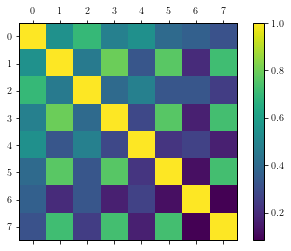

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow([[HoverF_cov[i][j] / np.sqrt(HoverF_cov[i][i] * HoverF_cov[j][j]) for j in range(8)] for i in range(8)], interpolation='nearest')
fig.colorbar(cax)

plt.show()

# Fit B->K

## Analysis Definition

In [24]:
for i in range(8):
    print("{} @ q2: {} = ({:.3f} +/- {:.3f}) 10^(-7)".format(HoverF_obs[i], -7 + 2*((i//2)%4), 10**7 * HoverF_means[i], 10**7 * np.sqrt(HoverF_cov[i][i])))

B->K::re_ratio_plus(q2) @ q2: -7 = (96.774 +/- 59.561) 10^(-7)
B->K::im_ratio_plus(q2) @ q2: -7 = (-13.082 +/- 2.982) 10^(-7)
B->K::re_ratio_plus(q2) @ q2: -5 = (199.528 +/- 45.049) 10^(-7)
B->K::im_ratio_plus(q2) @ q2: -5 = (-11.794 +/- 2.477) 10^(-7)
B->K::re_ratio_plus(q2) @ q2: -3 = (208.742 +/- 32.093) 10^(-7)
B->K::im_ratio_plus(q2) @ q2: -3 = (-9.162 +/- 1.809) 10^(-7)
B->K::re_ratio_plus(q2) @ q2: -1 = (104.403 +/- 14.513) 10^(-7)
B->K::im_ratio_plus(q2) @ q2: -1 = (-4.103 +/- 0.778) 10^(-7)


In [25]:
covariance = [[float(HoverF_cov[i,j]) for j in range(8)] for i in range(8)]

manual_constraints = {
     "B->K::HoverF": {
          'type': 'MultivariateGaussian(Covariance)',
          'dim': 8,
          'observables': HoverF_obs,
          'kinematics' : [{'q2': -7 + 2*((i//2)%4)} for i in range(8)],
          'options' : [{} for _ in range(8)],
          'means': [float(mean) for mean in HoverF_means],
          'covariance': covariance,
          'dof': 8
        }
    }

In [26]:
with open('BToK-nonlocal-data.yaml', 'w') as outfile:
    yaml.dump(manual_constraints["B->K::HoverF"], outfile, default_flow_style=False)

In [27]:
# Artificial HoverF constraints at negative q^2 -> allows a cross check with indep measurments. 

c = eos.Constraints()

for i, obs in enumerate(HoverF_obs):
    ce = c.insert(obs[:-4] + str(7 - 2*((i//2)%4)),
'''
type: Gaussian
observable: ''' + obs + '''
kinematics: {q2: ''' + str(-7 + 2*((i//2)%4)) + '''}
options: {}
mean: ''' + str(HoverF_means[i]) + '''
sigma-stat: {hi: ''' + str(np.sqrt(HoverF_cov[i][i])) + ', lo: ' + str(np.sqrt(HoverF_cov[i][i])) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')

In [28]:
fixed_parameters = {
    "b->sccbar::t_0": 4,
    "B->K::alpha^f+_0@BSZ2015":  0.33184135,
    "B->K::alpha^f+_1@BSZ2015": -0.96489682,
    "B->K::alpha^f+_2@BSZ2015": -0.30385271,
    "B->K::alpha^f0_1@BSZ2015":  0.33416387,
    "B->K::alpha^f0_2@BSZ2015":  0.00294223,
    "B->K::alpha^fT_0@BSZ2015":  0.32382196,
    "B->K::alpha^fT_1@BSZ2015": -1.02806629,
    "B->K::alpha^fT_2@BSZ2015": -0.39824964
}

In [29]:
priors =  [
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m7_plus@GRvDV2022', 'min': -0.000139, 'max':0.000212, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m7_plus@GRvDV2022', 'min': -1.21e-05, 'max':3.51e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m5_plus@GRvDV2022', 'min': -7.27e-05, 'max':0.000269, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m5_plus@GRvDV2022', 'min': -1.49e-05, 'max':4.55e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m3_plus@GRvDV2022', 'min': -4.04e-05, 'max':0.000363, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m3_plus@GRvDV2022', 'min': -1.83e-05, 'max':5.10e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m1_plus@GRvDV2022', 'min': -6.69e-05, 'max':0.000515, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m1_plus@GRvDV2022', 'min': -2.26e-05, 'max':4.55e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Abs_Hhat_at_Jpsi_plus@GRvDV2022', 'min': 0.00112, 'max':0.00132, 'type': 'uniform'},
]

In [30]:
likelihood = [
        'B^0->K^0Jpsi::BR@PDG:2020A',
#        'B^0->K^0psi2S::BR@PDG:2020A',
        'B->KJpsi::BR@PDG:2020A',
#        'B->Kpsi2S::BR@PDG:2020A',
]

In [35]:
start_point = [
        2.60361351e-05, -3.51954650e-06,  7.53183226e-05, -4.45213733e-06,
        1.29977711e-04, -5.70511544e-06,  1.89577011e-04, -7.44956465e-06,
        1.22519662e-03
]

In [36]:
analysis_args = {
    'fixed_parameters': fixed_parameters,
    'global_options': {'nonlocal-formfactor': 'GRvDV2022order5',
                       'form-factors': 'BSZ2015'},
    'manual_constraints': manual_constraints,
    'priors': priors,
    'likelihood': likelihood
}
analysis_allFF = eos.Analysis(**analysis_args)

INFO:EOS:Creating analysis with 9 priors, 2 EOS-wide constraints, 2 global options, 1 manually-entered constraints and 9 fixed parameters.
INFO:EOS:likelihood probably depends on 42 parameter(s) that do not appear in the prior; check prior?


In [37]:
get_gof(analysis_allFF, start_point) #p-value = 10.9

In [38]:
%%time
bfp_allFF = analysis_allFF.optimize(
#    start_point = start_point,
)
bfp_allFF = analysis_allFF.optimize(
    start_point = list(bfp_allFF.point),
    method = "TNC"
)
display(bfp_allFF.point)
bfp_allFF_gof = analysis_allFF.goodness_of_fit()
display(bfp_allFF_gof)

INFO:EOS:Optimization goal achieved after 21 function evaluations
INFO:EOS:Optimization goal achieved after 10 function evaluations


array([ 2.60361351e-05, -3.51954650e-06,  7.53183226e-05, -4.45213733e-06,
        1.29977711e-04, -5.70511544e-06,  1.89577011e-04, -7.44956465e-06,
        1.22519662e-03])

CPU times: user 18.4 ms, sys: 3.73 ms, total: 22.1 ms
Wall time: 12.9 ms


In [39]:
BRJpsi = eos.Observable.make("B->Kpsi::BR", analysis_allFF.parameters, eos.Kinematics(), eos.Options(**{"q": "d", "psi": "J/psi", 'nonlocal-formfactor': 'GRvDV2022order5'}))
BRpsi2S = eos.Observable.make("B->Kpsi::BR", analysis_allFF.parameters, eos.Kinematics(), eos.Options(**{"q": "d", "psi": "psi(2S)", 'nonlocal-formfactor': 'GRvDV2022order5'}))

display(BRJpsi, BRpsi2S, BRpsi2S.evaluate() / BRJpsi.evaluate()) # exp ratio ~ 0.7 

0.0

In [40]:
# Dispersive bound at the BFP:
eos.Observable.make("B->K::strong_bound", analysis_allFF.parameters, eos.Kinematics(), eos.Options(**{"q": "d", "psi": "J/psi", 'nonlocal-formfactor': 'GRvDV2022order5'}))

### Cross-check: did the local ff bfp changed?

In [41]:
q2_values = [-7, -5, -3, -1]
ff_obs_names = [
    "B->K::F_plus(q2)",
    "B->K::F_plus_T(q2)/F_plus(q2)"
    ]

ff_observables = [eos.Observable.make(
    obs_name,
    analysis_allFF.parameters,
    eos.Kinematics(q2=q2),
    eos.Options(**{'form-factors':'BSZ2015'})) for obs_name in ff_obs_names for q2 in q2_values]

I postdict the local ff points at negative q^2 to see if they changed significatively

In [42]:
display(np.array([obs.evaluate() for i, obs in enumerate(ff_observables)]))
display(np.array([(FToverF_mean[i] - obs.evaluate())/np.sqrt(FToverF_cov[i, i]) for i, obs in enumerate(ff_observables)]))

array([ 0.23126544,  0.25512848,  0.28249986,  0.31413273, -0.22082849,
       -0.15847258, -0.09550382, -0.03196744])

array([0.01259834, 0.01244939, 0.01226327, 0.01202608, 0.01325029,
       0.01361139, 0.0140225 , 0.01448698])

##  MCMC Sampling

In [39]:
NewChain = True

In [40]:
if not NewChain:
    basePath = '/home/t30/all/ge28qut/BTOSLL/data/BToK_Lagrange_nopsi2S'
    print("Reading from", basePath)
else:
    suffix = 'PMC'
    basePath = 'data/' + 'HoverF' + suffix + '_' + time_stamp
    if not os.path.exists(basePath):
        os.makedirs(os.path.abspath(basePath), exist_ok=True)
    print("Saving to", basePath)

Saving to data/HoverFPMC_2023-02-28-14-23-51-280545


In [41]:
mcmc_runs = 2

i_offset = 0

In [42]:
%%time
if NewChain:
    for i in tqdm(range(0, mcmc_runs), desc = 'Markov chains'):
        print("MC Markov Chain #{}".format(i+i_offset))
        rng = np.random.mtrand.RandomState(14408 + i + i_offset)
        samples, weights = analysis_allFF.sample(preruns = 15,
                                                 pre_N = 3000,
                                                 N = 20000,
                                                 stride = 5,
                                                 start_point = start_point,
                                                 cov_scale=1e-2,
                                                 rng=rng)
        print("Writing to", basePath+"/samples_mcmc_{}".format(i+i_offset))
        eos.data.MarkovChain.create(basePath+"/samples_mcmc_{}".format(i+i_offset),
                                    analysis_allFF.varied_parameters, samples, weights)

Markov chains:   0%|          | 0/2 [00:00<?, ?it/s]

MC Markov Chain #0


Pre-runs:   0%|          | 0/15 [00:00<?, ?it/s]

INFO:EOS:Prerun 0 out of 15
INFO:EOS:Prerun 0: acceptance rate is  30%
INFO:EOS:Prerun 1 out of 15
INFO:EOS:Prerun 1: acceptance rate is  27%
INFO:EOS:Prerun 2 out of 15
INFO:EOS:Prerun 2: acceptance rate is  27%
INFO:EOS:Prerun 3 out of 15
INFO:EOS:Prerun 3: acceptance rate is  29%
INFO:EOS:Prerun 4 out of 15
INFO:EOS:Prerun 4: acceptance rate is  25%
INFO:EOS:Prerun 5 out of 15
INFO:EOS:Prerun 5: acceptance rate is  27%
INFO:EOS:Prerun 6 out of 15
INFO:EOS:Prerun 6: acceptance rate is  28%
INFO:EOS:Prerun 7 out of 15
INFO:EOS:Prerun 7: acceptance rate is  28%
INFO:EOS:Prerun 8 out of 15
INFO:EOS:Prerun 8: acceptance rate is  26%
INFO:EOS:Prerun 9 out of 15
INFO:EOS:Prerun 9: acceptance rate is  26%
INFO:EOS:Prerun 10 out of 15
INFO:EOS:Prerun 10: acceptance rate is  25%
INFO:EOS:Prerun 11 out of 15
INFO:EOS:Prerun 11: acceptance rate is  28%
INFO:EOS:Prerun 12 out of 15
INFO:EOS:Prerun 12: acceptance rate is  26%
INFO:EOS:Prerun 13 out of 15
INFO:EOS:Prerun 13: acceptance rate is  27

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

...

Pre-runs:   0%|          | 0/15 [00:00<?, ?it/s]

INFO:EOS:Prerun 0 out of 15
INFO:EOS:Prerun 0: acceptance rate is  29%
INFO:EOS:Prerun 1 out of 15
INFO:EOS:Prerun 1: acceptance rate is  26%
INFO:EOS:Prerun 2 out of 15
INFO:EOS:Prerun 2: acceptance rate is  27%
INFO:EOS:Prerun 3 out of 15
INFO:EOS:Prerun 3: acceptance rate is  27%
INFO:EOS:Prerun 4 out of 15
INFO:EOS:Prerun 4: acceptance rate is  26%
INFO:EOS:Prerun 5 out of 15
INFO:EOS:Prerun 5: acceptance rate is  28%
INFO:EOS:Prerun 6 out of 15
INFO:EOS:Prerun 6: acceptance rate is  29%
INFO:EOS:Prerun 7 out of 15
INFO:EOS:Prerun 7: acceptance rate is  25%
INFO:EOS:Prerun 8 out of 15
INFO:EOS:Prerun 8: acceptance rate is  28%
INFO:EOS:Prerun 9 out of 15
INFO:EOS:Prerun 9: acceptance rate is  28%
INFO:EOS:Prerun 10 out of 15
INFO:EOS:Prerun 10: acceptance rate is  28%
INFO:EOS:Prerun 11 out of 15
INFO:EOS:Prerun 11: acceptance rate is  25%
INFO:EOS:Prerun 12 out of 15
INFO:EOS:Prerun 12: acceptance rate is  25%
INFO:EOS:Prerun 13 out of 15
INFO:EOS:Prerun 13: acceptance rate is  27

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:EOS:Main run: acceptance rate is  28%


Writing to data/HoverFPMC_2023-02-28-14-23-51-280545/samples_mcmc_1
CPU times: user 25.1 s, sys: 24.8 s, total: 49.9 s
Wall time: 22.1 s


In [43]:
mcmc_paths = [basePath + '/samples_mcmc_{}'.format(i) for i in range(i_offset, i_offset+mcmc_runs)]

chains    = [eos.data.MarkovChain(path).samples for path in mcmc_paths]
cweights  = [eos.data.MarkovChain(path).weights for path in mcmc_paths]
means     = [np.mean(chain, axis=0) for chain in chains]
variances = [np.var(chain,  axis=0) for chain in chains]

len(chains)

2

In [44]:
def bound(point):
    for p, v in zip(analysis_allFF.varied_parameters, point):
        p.set(v)
    bound = eos.Observable.make("B->K::strong_bound",
                                analysis_allFF.parameters,
                                eos.Kinematics(),
                                eos.Options(**{"q": "d", 'nonlocal-formfactor': 'GRvDV2022order5'}))
    return bound.evaluate()

concat_chains = np.concatenate(chains, axis=0)
concat_cweights = np.concatenate(cweights, axis=0)

from multiprocessing import Pool
with Pool(10) as p:
    bounds = p.map(bound, concat_chains)

168962.52169168222
243441.55287057738


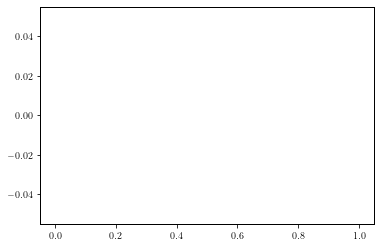

In [45]:
print(np.average(bounds, weights=concat_cweights))
print(np.std(bounds))

plt.hist(bounds, bins=np.linspace(0,1,100), weights=concat_cweights)

plt.show()

In [46]:
(np.max(cweights, axis=1), np.min(cweights, axis=1))

(array([207.86095291, 207.93479833]), array([186.8161196 , 186.48348095]))

In [47]:
chains_bfp = chains[np.argmax(np.max(cweights, axis=1))][np.argmax(cweights[np.argmax(np.max(cweights, axis=1))])]

if get_gof(analysis_allFF, chains_bfp).total_chi_square() < bfp_allFF_gof.total_chi_square():
    print("Best Fit Point found!")
    display(chains_bfp)
    display(get_gof(analysis_allFF, chains_bfp))
else:
    print("no Best Fit Point found...")

no Best Fit Point found...


In [48]:
chains_min = np.min([np.min(c, axis=0) for c in chains], axis=0)
chains_max = np.max([np.max(c, axis=0) for c in chains], axis=0)

for i, param in enumerate(priors):
    chain_min = chains_min[i]
    chain_max = chains_max[i]
    print("    {{ 'parameter': '{}', 'min': {:#.3g}, 'max':{:#.3g}, 'type': 'uniform'}},".format(
            param['parameter'],
            0.5*(3*chain_min - chain_max),
            0.5*(3*chain_max - chain_min)
        ))

    { 'parameter': 'B->Kccbar::Re_Hhat_at_m7_plus@GRvDV2022', 'min': -0.000143, 'max':0.000209, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m7_plus@GRvDV2022', 'min': -1.23e-05, 'max':4.23e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m5_plus@GRvDV2022', 'min': -0.000106, 'max':0.000286, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m5_plus@GRvDV2022', 'min': -1.59e-05, 'max':4.97e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m3_plus@GRvDV2022', 'min': -3.96e-05, 'max':0.000379, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m3_plus@GRvDV2022', 'min': -1.75e-05, 'max':5.19e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Re_Hhat_at_m1_plus@GRvDV2022', 'min': -6.39e-05, 'max':0.000512, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Im_Hhat_at_m1_plus@GRvDV2022', 'min': -2.17e-05, 'max':5.26e-06, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Abs_Hhat_at_Jpsi_plus@GRvDV2022', 'min': 

MC 2D Plots:   0%|          | 0/3 [00:00<?, ?it/s]

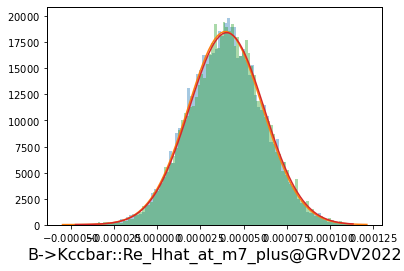

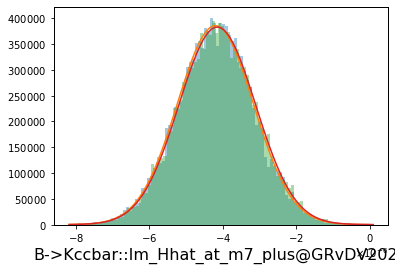

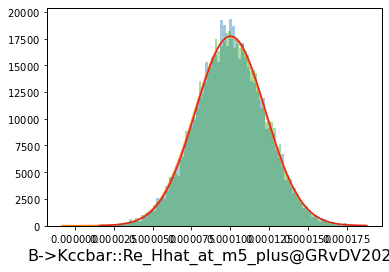

In [49]:
from matplotlib import rc
rc('text', usetex=False)

cols = 3
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    plt.clf()
    for i in range(mcmc_runs):
        myplt = plt.hist(chains[i][:][:,a], bins=100, density=True, alpha=0.4)
        plt.plot(myplt[1], stats.norm.pdf(myplt[1],
                                          means[i][a],
                                          np.sqrt(variances[i][a])))
    plt.xlabel(priors[a]["parameter"])    
    plt.show()

In [50]:
q2values  = [-7, -5, -3, -1]

observables = [
        eos.Observable.make(
    "B->K::"+part+"_ratio_plus(q2)",
    analysis_allFF.parameters,
    eos.Kinematics(q2=q2),
    eos.Options({'nonlocal-formfactor': 'GRvDV2022order5'})) for q2 in q2values for part in ["re", "im"]
    ]

parameters = [analysis_allFF.parameters[p["parameter"]] for p in priors]

def compute_obs(sample):
    for p, v in zip(parameters, sample):
        p.set(v)
    return [eos.Observable.evaluate(o) for o in observables]

H_observable_samples = np.array(process_map(compute_obs, np.concatenate(chains, axis=1), max_workers=10, chunksize=5))

  0%|          | 0/20000 [00:00<?, ?it/s]

## PMC Sampling

### Find Clusters

MC 2D Plots:   0%|          | 0/1 [00:00<?, ?it/s]

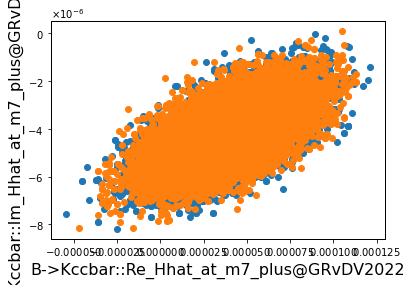

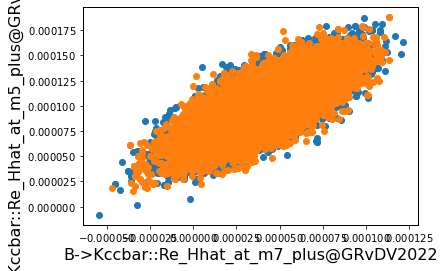

In [51]:
from matplotlib import rc
rc('text', usetex=False) 

cols, rows = (1,  3)
#cols, rows = (len(priors), len(priors))
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    for b in range(a + 1, rows):
        plt.clf()
        for i in range(mcmc_runs):
            plt.scatter(chains[i][:][:,a],chains[i][:][:,b])
        plt.xlabel(priors[a]["parameter"])
        plt.ylabel(priors[b]["parameter"])
#        plt.savefig('MCMC_output_'+str(a)+'_'+str(b)+'.pdf')
        plt.show()


In [52]:
K_g = 1
threshold = 1.006
cluster_out_path = basePath + '/samples_clusters'

groups    = pypmc.mix_adapt.r_value.r_group(means, variances, len(chains[0]), critical_r=threshold)
density   = pypmc.mix_adapt.r_value.make_r_gaussmix(chains, K_g=K_g, critical_r=threshold)
eos.data.MixtureDensity.create(cluster_out_path, density)

groups

[[0, 1]]

In [53]:
initial_proposal = eos.data.MixtureDensity(cluster_out_path).density()
#initial_proposal = eos.data.PMCSampler(basePath + '/samples_pmc').density()
print(len(initial_proposal.components))

1


MC 2D Plots:   0%|          | 0/1 [00:00<?, ?it/s]

row:   0%|          | 0/2 [00:00<?, ?it/s]

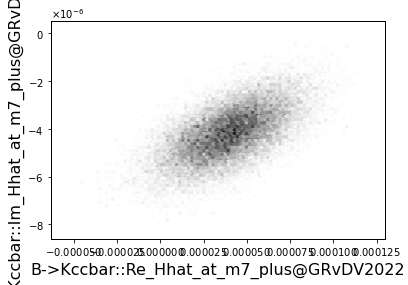

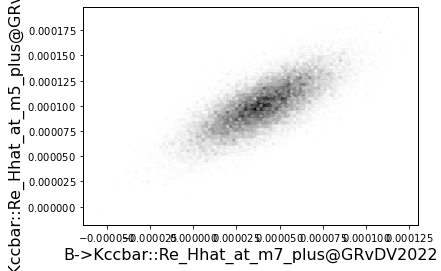

In [54]:
cols, rows = (1, 3)
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    for b in tqdm(range(a + 1, rows), desc = 'row'):
        plt.clf()
        pypmc.tools.plot_mixture(initial_proposal, i=a, j=b, cmap='jet')
        plt.hexbin(concat_chains[:][:,a],concat_chains[:][:,b], cmap='gray_r')
        plt.xlabel(priors[a]["parameter"])    
        plt.ylabel(priors[b]["parameter"]) 
        plt.show()

MC 2D Plots:   0%|          | 0/3 [00:00<?, ?it/s]

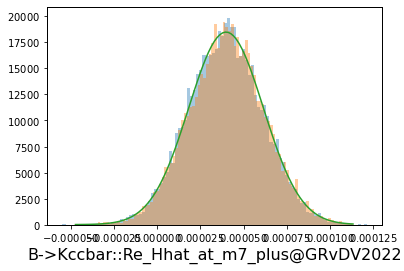

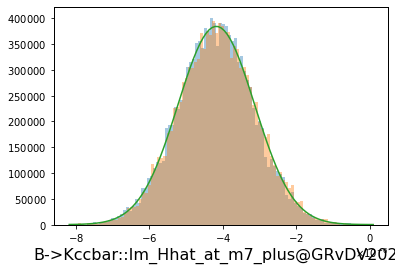

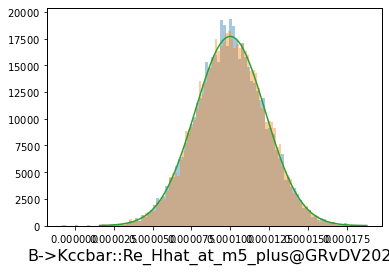

In [55]:
import scipy.stats as stats

cols = 3
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    plt.clf()
    for i in range(mcmc_runs):
        myplt = plt.hist(chains[i][:][:,a], bins=100, density=True, alpha=0.4)
    for c in range(len(initial_proposal.components)):
        plt.plot(myplt[1], stats.norm.pdf(myplt[1],
                                          initial_proposal.components[c].mu[a],
                                          np.sqrt(initial_proposal.components[c].sigma[a,a])))
    plt.xlabel(priors[a]["parameter"])    
    plt.show()

### Sampling

In [56]:
run_pmc = True

In [57]:
%%time
rng = np.random.mtrand.RandomState(1408)
if run_pmc:
    samples, weights, proposal = analysis_allFF.sample_pmc(initial_proposal,
                                                       rng=rng,
                                                       step_N = 5000 * len(initial_proposal.components),
                                                       steps = 15,
                                                       final_N = 100000,
                                                       pmc_iterations = 10,
                                                       pmc_lookback = 15
                                                      )
else:
    samples, weights, proposal = analysis_allFF.sample_pmc(initial_proposal,
                                                       rng=rng,
                                                       steps = 0,
                                                       final_N = 100000,
                                                      )

Adaptions:   0%|          | 0/15 [00:00<?, ?it/s]

INFO:EOS:Convergence diagnostics of the last samples after sampling in step 0: perplexity = 0.9974817152951937, ESS = 0.9950690764984023
INFO:EOS:Convergence diagnostics of all previous samples after sampling in step 0: perplexity = 0.9974817152951937, ESS = 0.9950690764984023
INFO:EOS:Convergence diagnostics of the last samples after sampling in step 1: perplexity = 0.9952518087439864, ESS = 0.9906463614759948
INFO:EOS:Convergence diagnostics of all previous samples after sampling in step 1: perplexity = 0.9963655440964556, ESS = 0.992850631423896
INFO:EOS:Convergence diagnostics of the last samples after sampling in step 2: perplexity = 0.9981621392102137, ESS = 0.9963258334757097
INFO:EOS:Convergence diagnostics of all previous samples after sampling in step 2: perplexity = 0.9969631833128105, ESS = 0.9940034697952626
INFO:EOS:Convergence diagnostics of the last samples after sampling in step 3: perplexity = 0.9984035963877966, ESS = 0.9967874022406775
INFO:EOS:Convergence diagnosti

CPU times: user 23.3 s, sys: 17.9 s, total: 41.2 s
Wall time: 20.9 s


In [58]:
eos.data.PMCSampler.create(basePath + '/pmc_sampler',
                           analysis_allFF.varied_parameters,
                           proposal,
                           sigma_test_stat=np.arange(0.5,10,.5),
                           samples=samples,
                           weights=weights,
                          )
eos.data.ImportanceSamples.create(basePath + '/importance_samples',
                                  analysis_allFF.varied_parameters,
                                  samples,
                                  weights,
                                  )

MC 2D Plots:   0%|          | 0/1 [00:00<?, ?it/s]

row:   0%|          | 0/2 [00:00<?, ?it/s]

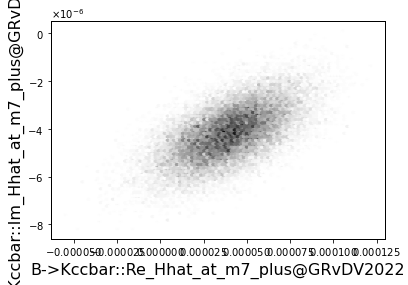

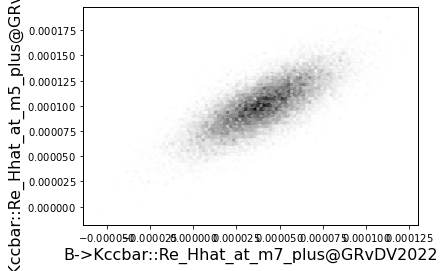

In [59]:
from matplotlib import rc
rc('text', usetex=False) 

cols, rows = (1, 3)
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    for b in tqdm(range(a + 1, rows), desc = 'row'):
        plt.clf()
        pypmc.tools.plot_mixture(proposal, i=a, j=b, cmap='jet')
        plt.hexbin(concat_chains[:,a],concat_chains[:][:,b], cmap='gray_r')
        plt.xlabel(priors[a]["parameter"])    
        plt.ylabel(priors[b]["parameter"])
        plt.savefig('mixture_density.png')
        plt.show()

MC 2D Plots:   0%|          | 0/2 [00:00<?, ?it/s]

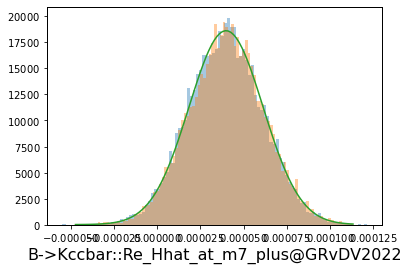

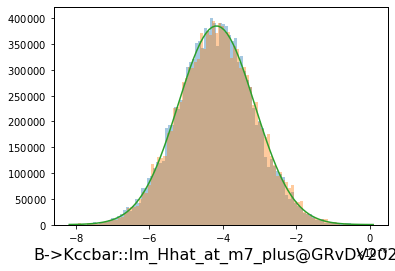

In [60]:
cols = 2
for a in tqdm(range(cols), desc = 'MC 2D Plots'):
    plt.clf()
    for i in range(mcmc_runs):
        myplt = plt.hist(chains[i][:][:,a], bins=100, density=True, alpha=0.4)
    for c in range(len(proposal.components)):
        plt.plot(myplt[1], stats.norm.pdf(myplt[1],
                                          proposal.components[c].mu[a],
                                          np.sqrt(proposal.components[c].sigma[a,a])))
    plt.xlabel(priors[a]["parameter"])    
    plt.show()

In [61]:
with open('BToKPosteriors.npy', 'wb') as f:
    np.save(f, np.average(samples, weights=weights, axis=0))
    np.save(f, np.cov(np.transpose(samples), aweights=weights))

## Cross-Check

In [83]:
def get_gof(analysis, param_array):
    for i, param in enumerate(analysis.init_args['priors']):
        analysis.parameters.set(param['parameter'], param_array[i])
    return analysis.goodness_of_fit()

In [84]:
delta_chi2s = [get_gof(analysis_allFF, sample).total_chi_square()-bfp_allFF_gof.total_chi_square() for sample in samples]

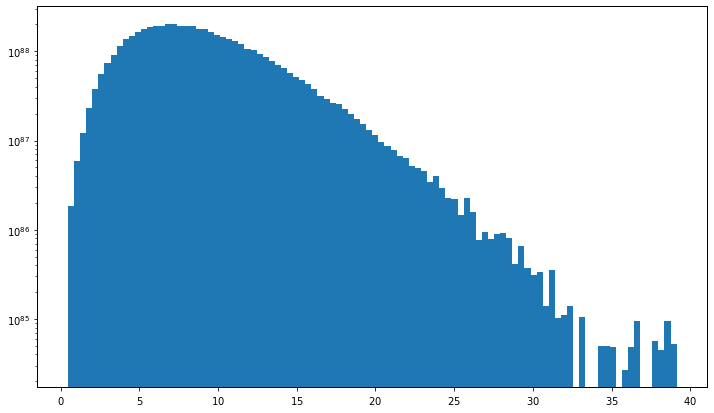

In [85]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

line = ax.hist(delta_chi2s, bins=100, weights=weights)

ax.set_yscale('log')

plt.show()

In [86]:
uncertainty_priors = priors + [
    { 'parameter': 'B->Kccbar::Arg_Hhat_at_Jpsi_plus@GRvDV2022',  'min': -np.pi, 'max': np.pi, 'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Abs_Hhat_at_psi2S_plus@GRvDV2022', 'min': 0.,     'max': 0.5,  'type': 'uniform'},
    { 'parameter': 'B->Kccbar::Arg_Hhat_at_psi2S_plus@GRvDV2022', 'min': -np.pi, 'max': np.pi, 'type': 'uniform'},
    ]

In [87]:
analysis_args = {
    'fixed_parameters': fixed_parameters,
    'global_options': {'tag': 'GvDV2020',
                       'nonlocal-formfactor':'GRvDV2022order5',
                       'form-factors': 'BSZ2015'},
    'manual_constraints': manual_constraints,
    'priors': uncertainty_priors,
    'likelihood': likelihood
}
analysis_uncertainty = eos.Analysis(**analysis_args)

INFO:EOS:Creating analysis with 12 priors, 2 EOS-wide constraints, 3 global options, 1 manually-entered constraints and 9 fixed parameters.
INFO:EOS:likelihood probably depends on 39 parameter(s) that do not appear in the prior; check prior?


In [88]:
ranges = np.array(analysis_uncertainty.bounds[-3:])
extra_samples = rng.rand(len(samples), 3) * (ranges[:,1] - ranges[:,0]) + ranges[:,0]

In [89]:
uncertainty_samples = np.concatenate((samples, extra_samples), axis=1)

## Plots

### Plot PMC parameters

In [90]:
from matplotlib import rc
rc('text', usetex=True) 

Collected samples 100000


B->Kccbar::Re_Hhat_at_m7_plus@GRvDV2022
{'68p': [1.852273341884609e-05, 6.111398036082069e-05],
 '95p': [-2.750262535143142e-06, 8.206162435044484e-05],
 'raw mean': 3.983625651436845e-05,
 'std': 2.127989317095602e-05,
 'weighted 68p': [1.8590664693841963e-05, 6.118226858622523e-05],
 'weighted 95p': [-2.6957944237076476e-06, 8.212910280556122e-05],
 'weighted mean': 3.99013284295239e-05,
 'weighted median': 3.9983530802046095e-05,
 'weighted std': 2.1278175530680938e-05}


B->Kccbar::Im_Hhat_at_m7_plus@GRvDV2022
{'68p': [-5.200910387162216e-06, -3.16259172853154e-06],
 '95p': [-6.216907526544545e-06, -2.131248293234824e-06],
 'raw mean': -4.181317130860351e-06,
 'std': 1.0225860267598958e-06,
 'weighted 68p': [-5.197809818904633e-06, -3.1540568728866964e-06],
 'weighted 95p': [-6.2172107693447966e-06, -2.1205788485200596e-06],
 'weighted mean': -4.175375252927348e-06,
 'weighted median': -4.1735678252519786e-06,
 'weighted std': 1.025718279260887e-06}


B->Kccbar::Re_Hhat_at_m5_plus@GRvDV2022
{'68p': [7.714452710864744e-05, 0.00012150650191279207],
 '95p': [5.5113220487046975e-05, 0.00014354503476043113],
 'raw mean': 9.93624838614699e-05,
 'std': 2.2146220627270997e-05,
 'weighted 68p': [7.73431041492388e-05, 0.00012163042326657276],
 'weighted 95p': [5.5246165103525563e-05, 0.00014365531659057978],
 'weighted mean': 9.950828760540589e-05,
 'weighted median': 9.949184634903622e-05,
 'weighted std': 2.2134295620051894e-05}


B->Kccbar::Im_Hhat_at_m5_plus@GRvDV2022
{'68p': [-6.368086431587303e-06, -4.028754536812113e-06],
 '95p': [-7.517921956470789e-06, -2.851832464090037e-06],
 'raw mean': -5.1929842671632434e-06,
 'std': 1.169261611458115e-06,
 'weighted 68p': [-6.363499589835468e-06, -4.020284355342891e-06],
 'weighted 95p': [-7.515947882787884e-06, -2.843652580025209e-06],
 'weighted mean': -5.186517290422788e-06,
 'weighted median': -5.185174341150388e-06,
 'weighted std': 1.171295600272847e-06}


...

B->Kccbar::Re_Hhat_at_m1_plus@GRvDV2022
{'68p': [0.0001975618530918006, 0.0002608551895697822],
 '95p': [0.00016570502258612997, 0.00029256377720725436],
 'raw mean': 0.0002291942691096648,
 'std': 3.170921657546731e-05,
 'weighted 68p': [0.00019761006168847684, 0.00026085467167601156],
 'weighted 95p': [0.00016580140724461933, 0.000292562844904163],
 'weighted mean': 0.00022921555951583845,
 'weighted median': 0.00022934477990168995,
 'weighted std': 3.168658200739376e-05}


B->Kccbar::Im_Hhat_at_m1_plus@GRvDV2022
{'68p': [-1.0109459614781034e-05, -6.760858693660812e-06],
 '95p': [-1.1774816964543529e-05, -5.0730593088119505e-06],
 'raw mean': -8.433755614634815e-06,
 'std': 1.6748075644045742e-06,
 'weighted 68p': [-1.010151732782009e-05, -6.746364043607898e-06],
 'weighted 95p': [-1.1769584086785364e-05, -5.051764488078852e-06],
 'weighted mean': -8.42123099836967e-06,
 'weighted median': -8.42485606999014e-06,
 'weighted std': 1.6786355977473528e-06}


B->Kccbar::Abs_Hhat_at_Jpsi_plus@GRvDV2022
{'68p': [0.0012119919283549386, 0.0012380256173401844],
 '95p': [0.0011991693469356004, 0.001251209635841473],
 'raw mean': 0.0012250090445541306,
 'std': 1.3005738424646611e-05,
 'weighted 68p': [0.001211989181732426, 0.0012379807595683358],
 'weighted 95p': [0.0011989384292238172, 0.0012508993412464271],
 'weighted mean': 0.0012249826990603076,
 'weighted median': 0.001225008464991049,
 'weighted std': 1.298463573477053e-05}


B->Kccbar::Arg_Hhat_at_Jpsi_plus@GRvDV2022
{'68p': [-2.151100396670729, 2.125595421381169],
 '95p': [-2.997314564144429, 2.9977645044838286],
 'raw mean': -0.011887524365934626,
 'std': 1.8111230653031818,
 'weighted 68p': [-2.151115791923816, 2.125600321580754],
 'weighted 95p': [-2.99737552497506, 2.9977713329186058],
 'weighted mean': -0.011928960044532191,
 'weighted median': -0.01372234300790047,
 'weighted std': 1.8111444750073642}


B->Kccbar::Abs_Hhat_at_psi2S_plus@GRvDV2022
{'68p': [0.08064361090939347, 0.42225309224568525],
 '95p': [0.01184590058344289, 0.4886467721729355],
 'raw mean': 0.2515182192293922,
 'std': 0.1441686487049036,
 'weighted 68p': [0.08066485603616237, 0.42227809236095565],
 'weighted 95p': [0.01184648164549481, 0.4886467727966532],
 'weighted mean': 0.2515466113239383,
 'weighted median': 0.25222857727433684,
 'weighted std': 0.14417353747933592}
B->Kccbar::Arg_Hhat_at_psi2S_plus@GRvDV2022
{'68p': [-2.1322009579438865, 2.1486793218464544],
 '95p': [-2.994809782996723, 3.0026060222228703],
 'raw mean': 0.00490288844000465,
 'std': 1.8139691738095527,
 'weighted 68p': [-2.1323884835807707, 2.148566632275682],
 'weighted 95p': [-2.994810174939888, 3.0025627350891],
 'weighted mean': 0.004784461834035261,
 'weighted median': -0.0066544411202523815,
 'weighted std': 1.8139658380488584}


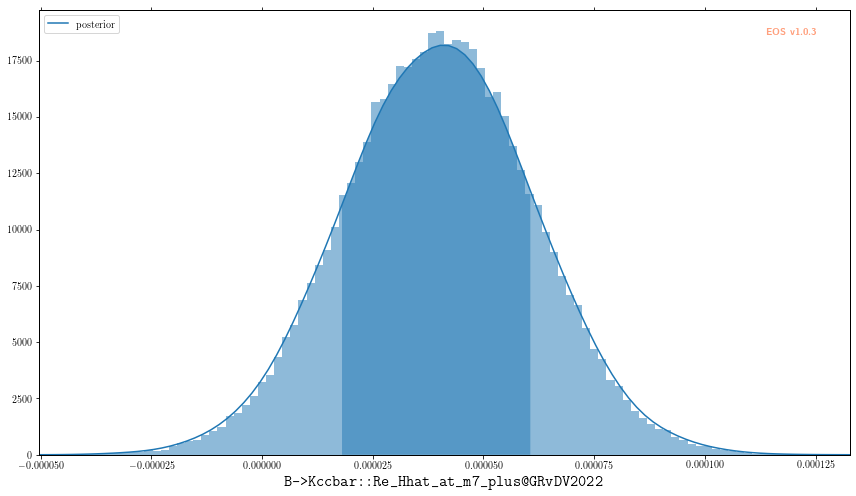

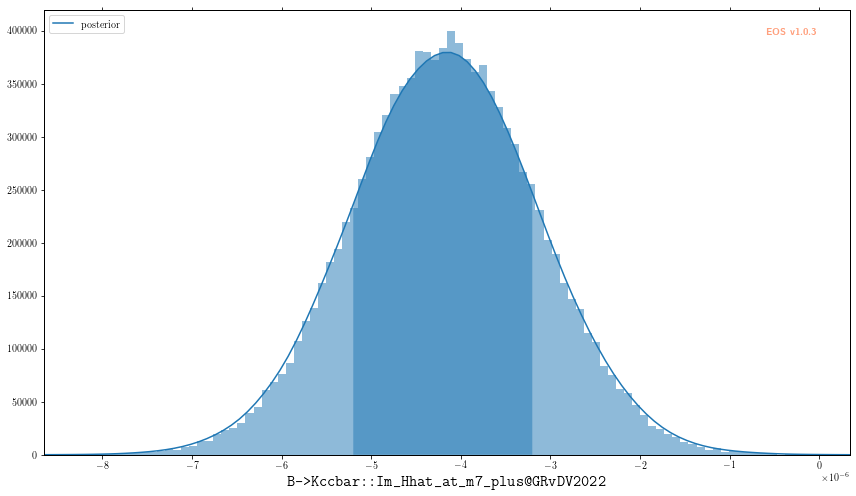

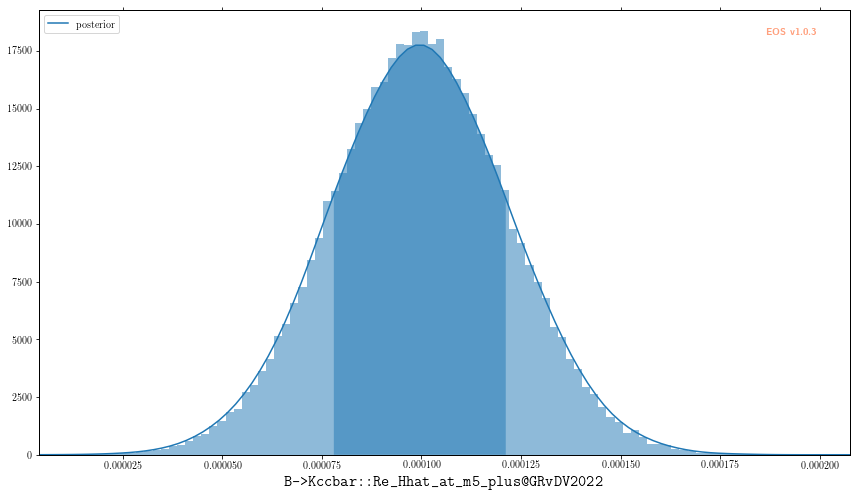

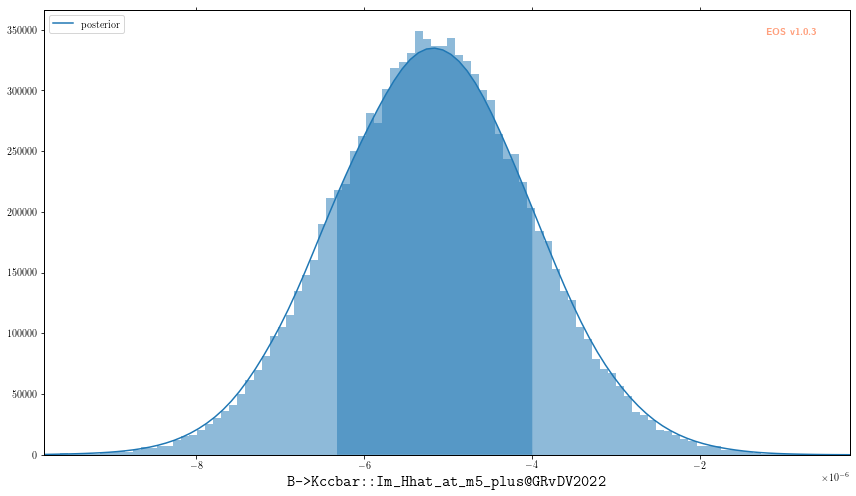

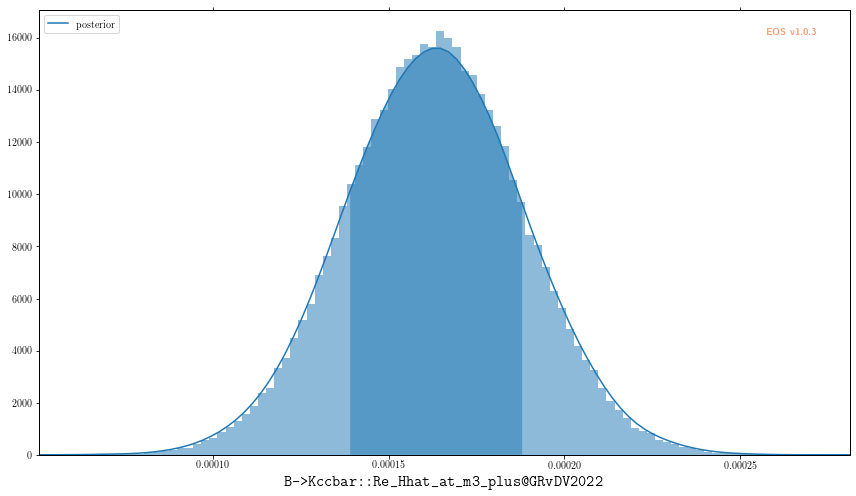

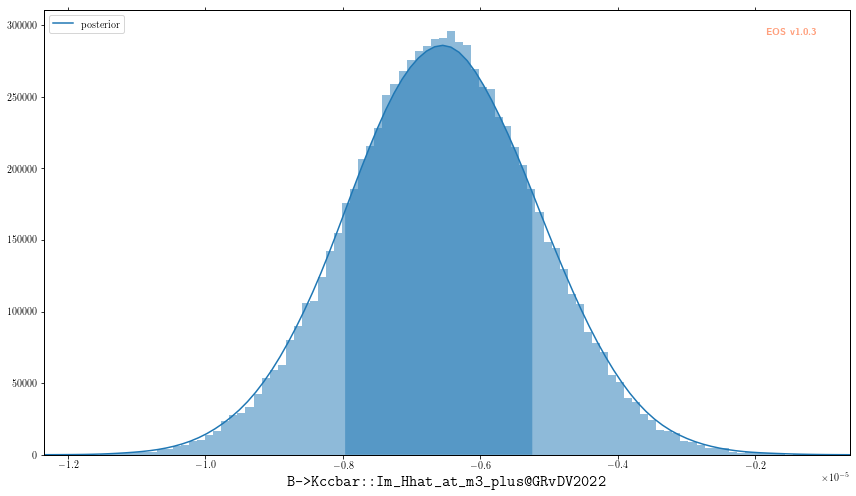

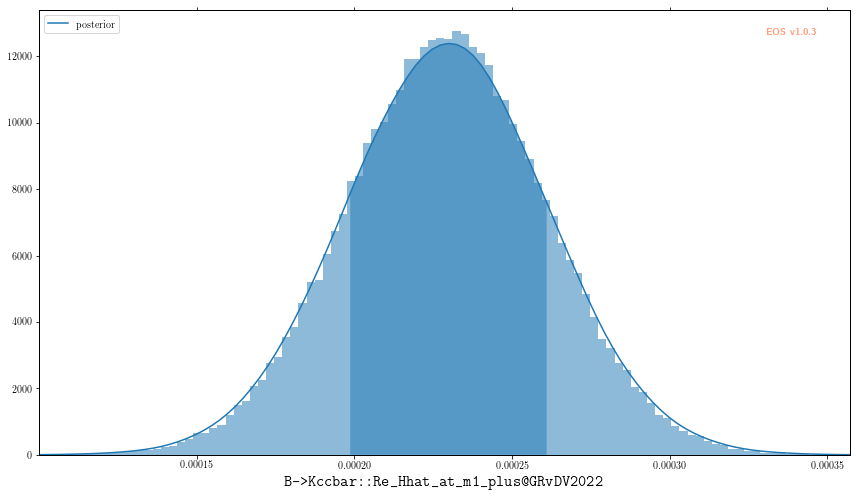

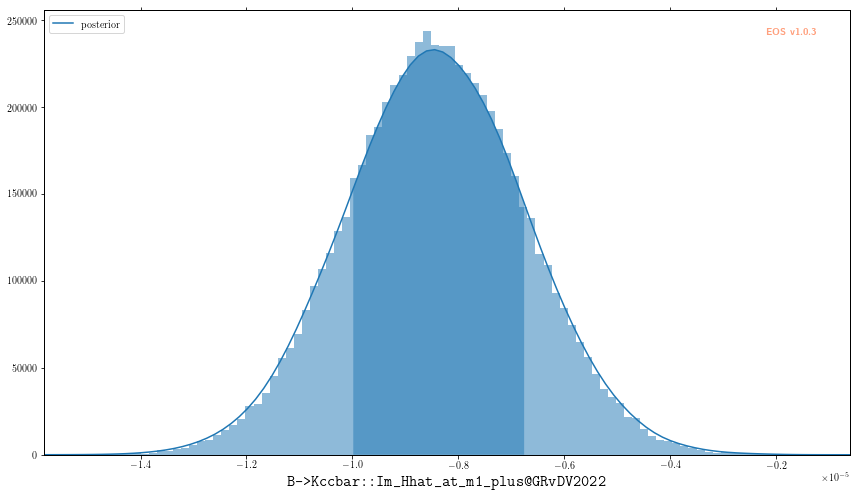

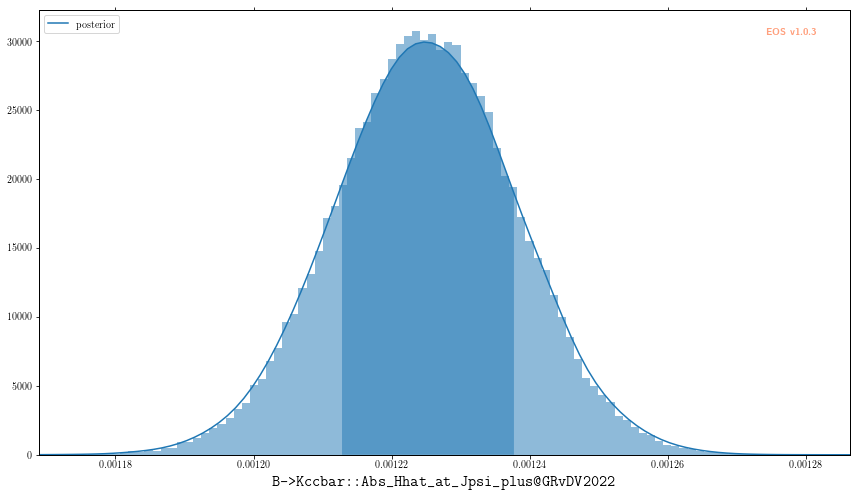

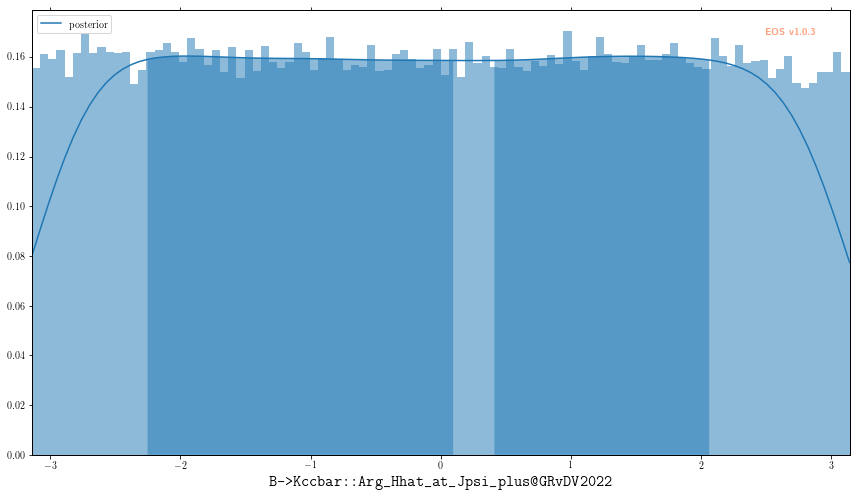

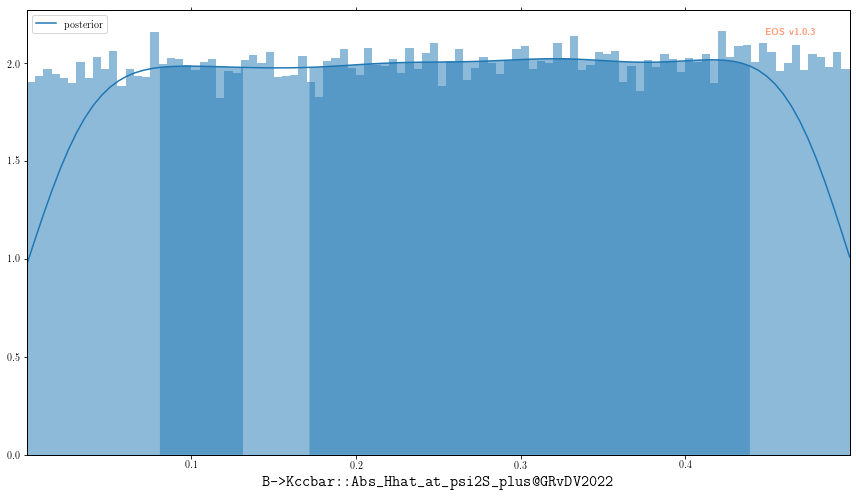

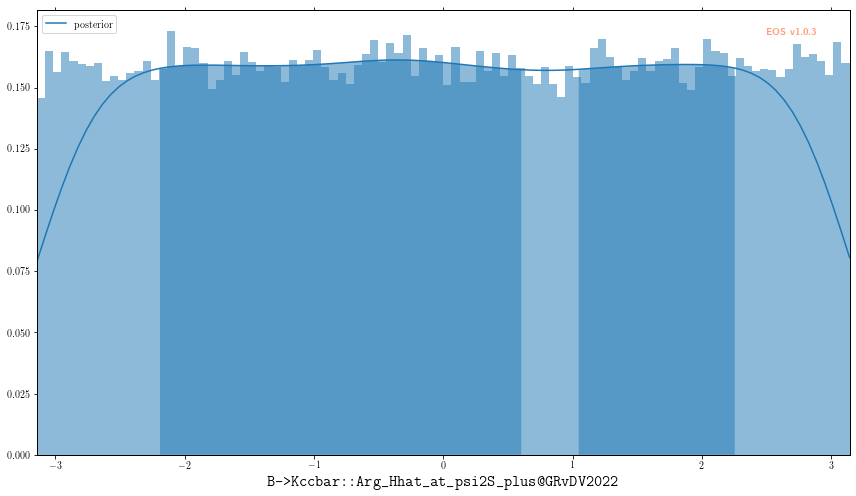

In [92]:
samples_pmc = eos.data.ImportanceSamples(basePath + '/importance_samples')
print("Collected samples", len(samples_pmc.weights))

#samples = samples_pmc.samples
#weights = samples_pmc.weights/np.sum(samples_pmc.weights)

posts = {}
import pprint as pp

pos_params = {}
parameter_index = 1
for parameter_index in range(0, len(uncertainty_priors)):
    parameter = uncertainty_priors[parameter_index]
    param_samples = uncertainty_samples[:, parameter_index]
    x_range = [ np.min(uncertainty_samples[:, parameter_index]), np.max(uncertainty_samples[:, parameter_index]) ]
    
    plot_args = {
        'plot': {
            'x': { 'label': r'\verb|'+parameter['parameter']+'|', 'range': x_range, 'format': '${x:.2f}$' },
            'legend': { 'location': 'upper left' }
        },
        'contents': [
            {
                'type': 'histogram',
                'data': { 'samples': param_samples, 'weights': weights }
            },
            {
                'type': 'kde', 'color': 'C0', 'label': 'posterior', 'bandwidth': 2,
                'data': { 'samples': param_samples, 'weights': weights }
            }
        ]
    }
    eos.plot.Plotter(plot_args).plot()
    
    mean_w = np.average(param_samples, weights=weights)
    var_w  = np.sqrt(np.average((param_samples - mean_w)**2, weights=weights))
    posts.update({parameter['parameter']: {
            # use item() method to get native python objects from numpy
            'raw mean': np.average(param_samples).item(),
            'weighted median': wquantiles.median(param_samples, weights),
            'weighted mean': mean_w.item(),
            'std': np.std(param_samples).item(),
            'weighted std': var_w.item(),
            '68p': [x.item() for x in np.percentile(param_samples, [(100 - 68.27)/2, (100 + 68.27)/2])],
            'weighted 68p': [wquantiles.quantile(param_samples, weights, (100 - 68.27)/2/100).item(),
                             wquantiles.quantile(param_samples, weights, (100 + 68.27)/2/100).item()],
            '95p': [x.item() for x in np.percentile(param_samples, [(100 - 95.45)/2, (100 + 95.45)/2])],
            'weighted 95p': [wquantiles.quantile(param_samples, weights, (100 - 95.45)/2/100).item(),
                             wquantiles.quantile(param_samples, weights, (100 + 95.45)/2/100).item()],
        }})
    pos_params.update({parameter['parameter']: posts[parameter['parameter']]['weighted mean']})
    print(parameter['parameter'])
    print(len(parameter['parameter']) * '=')
    pp.pprint(posts[parameter['parameter']])

In [93]:
def weak_bound(point):
    for p, v in zip(analysis_uncertainty.varied_parameters, point):
        p.set(v)
    bound = eos.Observable.make("B->K::weak_bound",
                                analysis_uncertainty.parameters,
                                eos.Kinematics(),
                                eos.Options(**{"q": "u", 'nonlocal-formfactor': 'GRvDV2022order5'}))
    return bound.evaluate()

def strong_bound(point):
    for p, v in zip(analysis_uncertainty.varied_parameters, point):
        p.set(v)
    bound = eos.Observable.make("B->K::strong_bound",
                                analysis_uncertainty.parameters,
                                eos.Kinematics(),
                                eos.Options(**{"q": "u", 'nonlocal-formfactor': 'GRvDV2022order5'}))
    return bound.evaluate()

In [94]:
s_bounds = []
w_bounds = []
s_bounded_weights = []
w_bounded_weights = []

for w, s in zip(weights, uncertainty_samples):
    s_bound = strong_bound(s)
    w_bound = weak_bound(s)
    s_bounds.append(s_bound)
    w_bounds.append(w_bound)

    if s_bound < 1.:
        s_bounded_weights.append(w)
        w_bounded_weights.append(w)
    elif w_bound < 1. :
        s_bounded_weights.append(w * np.exp(-0.5 * ((s_bound - 1.) / 0.1)**2))
        w_bounded_weights.append(w)
    else:
        s_bounded_weights.append(w * np.exp(-0.5 * ((s_bound - 1.) / 0.1)**2))
        w_bounded_weights.append(w * np.exp(-0.5 * ((w_bound - 1.) / 0.1)**2))

s_bounded_weights = np.array(s_bounded_weights)
w_bounded_weights = np.array(w_bounded_weights)

print("Number of samples: {}, weakly bounded: {}, strongly bounded {}".format(
        np.count_nonzero(weights),
        np.count_nonzero(np.array(w_bounds)<1),
        np.count_nonzero(np.array(s_bounds)<1)
    ))

Number of samples: 100000, weakly bounded: 15333, strongly bounded 8739


In [95]:
observables = [eos.Observable.make('B->Kpsi::BR', analysis_uncertainty.parameters,
                                   eos.Kinematics(), eos.Options({'q': 'u', 'psi': 'J/psi', 'nonlocal-formfactor': 'GRvDV2022order5'})),
               eos.Observable.make('B->Kpsi::BR', analysis_uncertainty.parameters,
                                   eos.Kinematics(), eos.Options({'q': 'u', 'psi': 'psi(2S)', 'nonlocal-formfactor': 'GRvDV2022order5'}))]

parameters = [analysis_uncertainty.parameters[p["parameter"]] for p in uncertainty_priors]

def compute_obs(sample):
    for p, v in zip(parameters, sample):
        p.set(v)
    return [eos.Observable.evaluate(o) for o in observables]

observable_samples = np.array(process_map(compute_obs, uncertainty_samples, max_workers=10, chunksize=5))

In [96]:
print('PDG2020A: ')
print('    BR(B->KJ/psi)   = (10.06 +/- 0.27) 10^-4')
print('    BR(B->Kpsi(2S)) = ( 6.19 +/- 0.22) 10^-4')
print()
print('Postdiction w/o bounds: ')
print('    BR(B->KJ/psi)   = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,0], weights=weights), 10**4 * wstd(observable_samples[:,0], weights=weights)))
print('    BR(B->Kpsi(2S)) = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,1], weights=weights), 10**4 * wstd(observable_samples[:,1], weights=weights)))
print()
#print('Postdiction w/ weak bound: ')
#print('    BR(B->KJ/psi)   = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,0], weights=w_bounded_weights), 10**4 * wstd(observable_samples[:,0], weights=w_bounded_weights)))
#print('    BR(B->Kpsi(2S)) = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,1], weights=w_bounded_weights), 10**4 * wstd(observable_samples[:,1], weights=w_bounded_weights)))
#print()
print('Postdiction w/ strong bound: ')
print('    BR(B->KJ/psi)   = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,0], weights=s_bounded_weights), 10**4 * wstd(observable_samples[:,0], weights=s_bounded_weights)))
print('    BR(B->Kpsi(2S)) = ({:#.3g} +/- {:#.3g}) 10^-4'.format(10**4 * np.average(observable_samples[:,1], weights=s_bounded_weights), 10**4 * wstd(observable_samples[:,1], weights=s_bounded_weights)))

PDG2020A: 
    BR(B->KJ/psi)   = (10.06 +/- 0.27) 10^-4
    BR(B->Kpsi(2S)) = ( 6.19 +/- 0.22) 10^-4

Postdiction w/o bounds: 
    BR(B->KJ/psi)   = (9.78 +/- 0.207) 10^-4
    BR(B->Kpsi(2S)) = (3.51e+03 +/- 3.11e+03) 10^-4

Postdiction w/ strong bound: 
    BR(B->KJ/psi)   = (9.78 +/- 0.205) 10^-4
    BR(B->Kpsi(2S)) = (1.49e+03 +/- 1.88e+03) 10^-4


### Plot H_lambda/F_lambda

In [97]:
npoints = 200
q2values  = np.linspace(-8,  9, npoints)

observables = [
        eos.Observable.make(
    "B->K::"+part+"_ratio_"+polarization+"(q2)",
    analysis_uncertainty.parameters,
    eos.Kinematics(q2=q2),
    eos.Options({'nonlocal-formfactor': 'GRvDV2022order5'})) for part in ["re", "im"] for polarization in ["plus"] for q2 in q2values
    ]

In [98]:
def compute_obs(sample):
    for p, v in zip(parameters, sample):
        p.set(v)
    return [eos.Observable.evaluate(o) for o in observables]

In [99]:
H_observable_samples = np.array(process_map(compute_obs, uncertainty_samples, max_workers=10, chunksize=5))

(<Figure size 864x504 with 1 Axes>,
 <AxesSubplot:xlabel='$q^2$\\,[$\\textnormal{GeV}^2$]', ylabel='$Re(H_\\lambda)/F_\\lambda$'>)

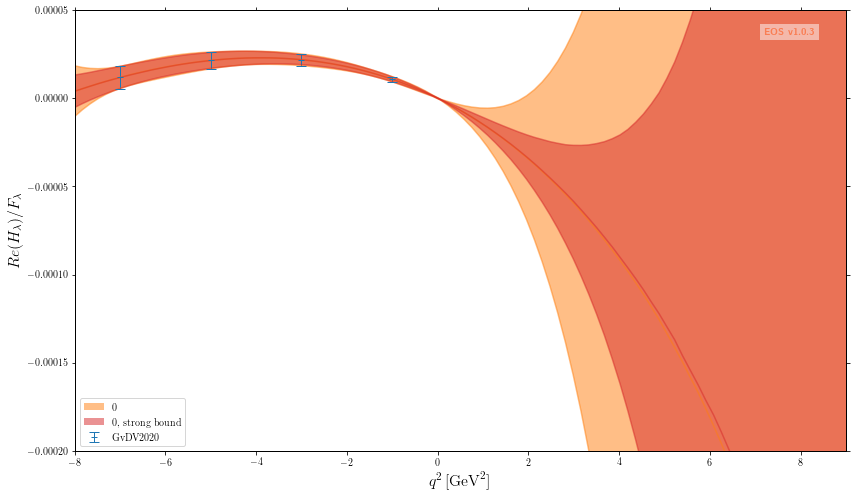

In [100]:
plot_re_H_args = {
    'plot': {
        'x': { 'label': r'$q^2$', 'unit': r'$\textnormal{GeV}^2$',  'range': [-8, 9] },
        'y': { 'label': r'$Re(H_\lambda)/F_\lambda$', 'range': [-2e-4,  5e-5] },
        'legend': { 'location': 'lower left' }
    },
    'contents': [
        {
            'label': r'$0$',
            'type': 'uncertainty',
            'color': 'C1',
            'range': [-8, 10],
            'data': { 'samples': H_observable_samples[:,:npoints], 'weights': weights, 'xvalues': q2values }
        },
#        {
#            'label': r'$0$, weak bound',
#            'type': 'uncertainty',
#            'color': 'C2',
#            'range': [-8, 10],
#            'data': { 'samples': H_observable_samples[:,:npoints], 'weights': w_bounded_weights, 'xvalues': q2values }
#        },
        {
            'label': r'$0$, strong bound',
            'type': 'uncertainty',
            'color': 'C3',
            'range': [-8, 10],
            'data': { 'samples': H_observable_samples[:,:npoints], 'weights': s_bounded_weights, 'xvalues': q2values }
        },
        {
            'label': r'GvDV2020',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::re_ratio_plus7',
            'observable': 'B->K::re_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::re_ratio_plus5',
            'observable': 'B->K::re_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::re_ratio_plus3',
            'observable': 'B->K::re_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::re_ratio_plus1',
            'observable': 'B->K::re_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        }
    ]
}
eos.plot.Plotter(plot_re_H_args).plot()

(<Figure size 864x504 with 1 Axes>,
 <AxesSubplot:xlabel='$q^2$\\,[$\\textnormal{GeV}^2$]', ylabel='$Im(H_\\lambda)/F_\\lambda$'>)

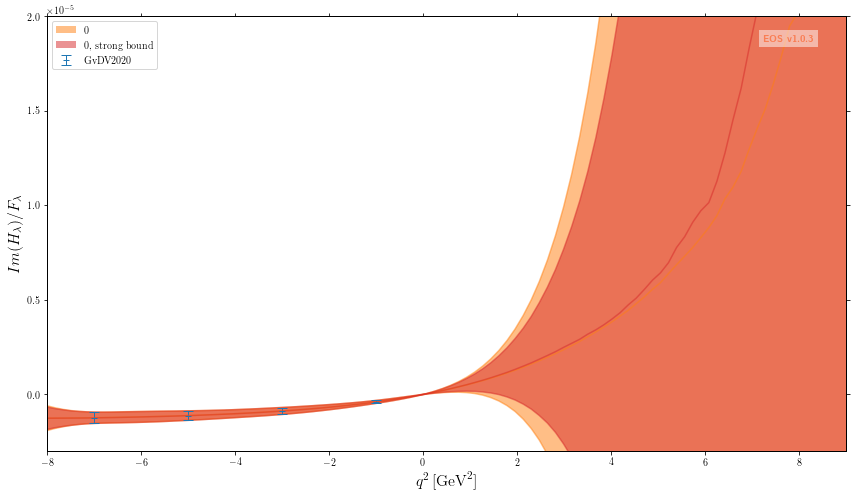

In [101]:
plot_im_H_args = {
    'plot': {
        'x': { 'label': r'$q^2$', 'unit': r'$\textnormal{GeV}^2$',  'range': [-8, 9] },
        'y': { 'label': r'$Im(H_\lambda)/F_\lambda$', 'range': [-3e-6,  2e-5] },
        'legend': { 'location': 'upper left' }
    },
    'contents': [
        {
            'label': r'$0$',
            'type': 'uncertainty',
            'color': 'C1',
            'range': [-8, 10],
            'data': { 'samples': H_observable_samples[:,npoints:2*npoints], 'weights': weights, 'xvalues': q2values }
        },
#        {
#            'label': r'$0$, weak bound',
#            'type': 'uncertainty',
#            'color': 'C2',
#            'range': [-8, 10],
#            'data': { 'samples': H_observable_samples[:,npoints:2*npoints], 'weights': w_bounded_weights, 'xvalues': q2values }
#        },
        {
            'label': r'$0$, strong bound',
            'type': 'uncertainty',
            'color': 'C3',
            'range': [-8, 10],
            'data': { 'samples': H_observable_samples[:,npoints:2*npoints], 'weights': s_bounded_weights, 'xvalues': q2values }
        },
        {
            'label': r'GvDV2020',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::im_ratio_plus7',
            'observable': 'B->K::im_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::im_ratio_plus5',
            'observable': 'B->K::im_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::im_ratio_plus3',
            'observable': 'B->K::im_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::im_ratio_plus1',
            'observable': 'B->K::im_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        }
    ]
}
eos.plot.Plotter(plot_im_H_args).plot()

### Cross-checks plot: H and Hhat

In [102]:
# Artificial constraint to visualize the B->Kpsi constraints
m_Bd    = analysis_uncertainty.parameters["mass::B_d"].evaluate()
tau_Bd  = analysis_uncertainty.parameters["life_time::B_d"].evaluate()
m_Kd    = analysis_uncertainty.parameters["mass::K_d"].evaluate()
m_Bu    = analysis_uncertainty.parameters["mass::B_u"].evaluate()
tau_Bu  = analysis_uncertainty.parameters["life_time::B_u"].evaluate()
m_Ku    = analysis_uncertainty.parameters["mass::K_u"].evaluate()
m_Jpsi  = analysis_uncertainty.parameters["mass::J/psi"].evaluate()
m_psi2S = analysis_uncertainty.parameters["mass::psi(2S)"].evaluate()
f_Jpsi  = analysis_uncertainty.parameters["decay-constant::J/psi"].evaluate()
f_psi2S = analysis_uncertainty.parameters["decay-constant::psi(2S)"].evaluate()
g_fermi = analysis_uncertainty.parameters["WET::G_Fermi"].evaluate()
hbar    = analysis_uncertainty.parameters["QM::hbar"].evaluate()
s_0     = analysis_uncertainty.parameters["b->sccbar::t_0"].evaluate()
ckm_cb  = 0.041
ckm_cs  = 0.987

s_p     = 4.0 * analysis_uncertainty.parameters["mass::D^0"].evaluate()**2

def kallen(m_B, m_K, m):
    return m_B**4 + m_K**4 + m**4 - 2 * m_B**2 * m_K**2 - 2 * m_B**2 * m**2 - 2 * m**2 * m_K**2
def z(q2):
    return (pow(s_p - q2, 0.5) - pow(s_p - s_0, 0.5)) / (pow(s_p - q2, 0.5) + pow(s_p - s_0, 0.5))

def blaschke(q2):
    return (z(q2) - z(m_Jpsi**2)) / (1.0 - z(q2) * z(m_Jpsi**2).conjugate()) \
         * (z(q2) - z(m_psi2S**2)) / (1.0 - z(q2) * z(m_psi2S**2).conjugate())

dzds_mJpsi  = -pow(s_p - s_0, 0.5) * pow(s_p - m_Jpsi**2, -0.5) * pow(pow(s_p - m_Jpsi**2, 0.5) + pow(s_p - s_0, 0.5), -2);
dzds_mpsi2S = -pow(s_p - s_0, 0.5) * pow(s_p - m_psi2S**2, -0.5) * pow(pow(s_p - m_psi2S**2, 0.5) + pow(s_p - s_0, 0.5), -2);

F0d_mJpsi = eos.Observable.make("B->K::F_plus(q2)", analysis_uncertainty.parameters,
            eos.Kinematics(q2=m_Jpsi**2), eos.Options({"q": "d", "form-factors": "BSZ2015"})).evaluate()

F0d_mpsi2S = eos.Observable.make("B->K::F_plus(q2)", analysis_uncertainty.parameters,
            eos.Kinematics(q2=m_psi2S**2), eos.Options({"q": "d", "form-factors":"BSZ2015"})).evaluate()

F0u_mJpsi = eos.Observable.make("B->K::F_plus(q2)", analysis_uncertainty.parameters,
            eos.Kinematics(q2=m_Jpsi**2), eos.Options({"q": "u", "form-factors": "BSZ2015"})).evaluate()

F0u_mpsi2S = eos.Observable.make("B->K::F_plus(q2)", analysis_uncertainty.parameters,
            eos.Kinematics(q2=m_psi2S**2), eos.Options({"q": "u", "form-factors":"BSZ2015"})).evaluate()

In [103]:
prefactor_Bd_Jpsi = abs(dzds_mJpsi) / abs(F0d_mJpsi) \
  * abs(z(m_Jpsi**2) - z(m_psi2S**2)) / (1 - abs(z(m_Jpsi**2))**2) / abs(1 - z(m_Jpsi**2) * z(m_psi2S**2).conjugate()) \
  * f_Jpsi * m_Jpsi**2 / g_fermi / abs(ckm_cb * ckm_cs) / kallen(m_Bd, m_Kd, m_Jpsi)**0.75 \
  * ( 2 * np.pi * hbar / tau_Bd / m_Bd)**0.5

prefactor_Bu_Jpsi = abs(dzds_mJpsi) / abs(F0u_mJpsi) \
  * abs(z(m_Jpsi**2) - z(m_psi2S**2)) / (1 - abs(z(m_Jpsi**2))**2) / abs(1 - z(m_Jpsi**2) * z(m_psi2S**2).conjugate()) \
  * f_Jpsi * m_Jpsi**2 / g_fermi / abs(ckm_cb * ckm_cs) / kallen(m_Bu, m_Ku, m_Jpsi)**0.75 \
  * ( 2 * np.pi * hbar / tau_Bu / m_Bu)**0.5

PHoverFfromBdToKdJpsiBR = {
    'mean': prefactor_Bd_Jpsi * np.sqrt(8.68e-4),
    'stat': prefactor_Bd_Jpsi * np.sqrt(3e-5) / 17 # I should remove the local ff uncertainty here! -> empirically divide by 18
}

PHoverFfromBuToKuJpsiBR = {
    'mean': prefactor_Bu_Jpsi * np.sqrt(10.06e-4),
    'stat': prefactor_Bu_Jpsi * np.sqrt(2.7e-5) / 17 # I should remove the local ff uncertainty here! -> empirically divide by 18
}

In [104]:
prefactor_Bd_psi2S = abs(dzds_mpsi2S) / abs(F0d_mpsi2S) \
  * abs(z(m_psi2S**2) - z(m_Jpsi**2)) / (1 - abs(z(m_psi2S**2))**2) / abs(1 - z(m_psi2S**2) * z(m_Jpsi**2).conjugate()) \
  * f_psi2S * m_psi2S**2 / g_fermi / abs(ckm_cb * ckm_cs) / kallen(m_Bd, m_Kd, m_psi2S)**0.75 \
  * ( 2 * np.pi * hbar / tau_Bd / m_Bd)**0.5

prefactor_Bu_psi2S = abs(dzds_mpsi2S) / abs(F0u_mpsi2S) \
  * abs(z(m_psi2S**2) - z(m_Jpsi**2)) / (1 - abs(z(m_psi2S**2))**2) / abs(1 - z(m_psi2S**2) * z(m_Jpsi**2).conjugate()) \
  * f_psi2S * m_psi2S**2 / g_fermi / abs(ckm_cb * ckm_cs) / kallen(m_Bu, m_Ku, m_psi2S)**0.75 \
  * ( 2 * np.pi * hbar / tau_Bu / m_Bu)**0.5

PHoverFfromBdToKdpsi2SBR = {
    'mean': prefactor_Bd_psi2S * np.sqrt(5.8e-4),
    'stat': prefactor_Bd_psi2S * np.sqrt(5e-5) # I should remove the local ff uncertainty here!
}

PHoverFfromBuToKupsi2SBR = {
    'mean': prefactor_Bu_psi2S * np.sqrt(6.19e-4),
    'stat': prefactor_Bu_psi2S * np.sqrt(2.2e-5) # I should remove the local ff uncertainty here!
}

In [105]:
eos.Constraints().insert("B->K::abs_P_ratio_plus_fromBdToKdJpsiBR",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: ''' + str(m_Jpsi**2) + '''}
options: {}
mean: ''' + str(PHoverFfromBdToKdJpsiBR["mean"]) + '''
sigma-stat: {hi: ''' + str(PHoverFfromBdToKdJpsiBR["stat"]) + ', lo: ' + str(PHoverFfromBdToKdJpsiBR["stat"]) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')
eos.Constraints().insert("B->K::abs_P_ratio_plus_fromBdToKdpsi2SBR",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: ''' + str(m_psi2S**2) + '''}
options: {}
mean: ''' + str(PHoverFfromBdToKdpsi2SBR["mean"]) + '''
sigma-stat: {hi: ''' + str(PHoverFfromBdToKdpsi2SBR["stat"]) + ', lo: ' + str(PHoverFfromBdToKdpsi2SBR["stat"]) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')

eos.Constraints().insert("B->K::abs_P_ratio_plus_fromBuToKuJpsiBR",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: ''' + str(m_Jpsi**2) + '''}
options: {}
mean: ''' + str(PHoverFfromBuToKuJpsiBR["mean"]) + '''
sigma-stat: {hi: ''' + str(PHoverFfromBuToKuJpsiBR["stat"]) + ', lo: ' + str(PHoverFfromBuToKuJpsiBR["stat"]) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')
eos.Constraints().insert("B->K::abs_P_ratio_plus_fromBuToKupsi2SBR",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: ''' + str(m_psi2S**2) + '''}
options: {}
mean: ''' + str(PHoverFfromBuToKupsi2SBR["mean"]) + '''
sigma-stat: {hi: ''' + str(PHoverFfromBuToKupsi2SBR["stat"]) + ', lo: ' + str(PHoverFfromBuToKupsi2SBR["stat"]) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')

In [106]:
# The uncertainties are naively estimated atm

eos.Constraints().insert("B->K::abs_P_ratio_plus7",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: -7}
options: {}
mean: ''' + str( abs(blaschke(-7) * (HoverF_means[0] + 1j * HoverF_means[1])) ) + '''
sigma-stat: {hi: ''' + str(blaschke(-7) * np.sqrt(HoverF_cov[0][0])) + ', lo: ' + str(blaschke(-7) * np.sqrt(HoverF_cov[0][0])) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')
eos.Constraints().insert("B->K::abs_P_ratio_plus5",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: -5}
options: {}
mean: ''' + str( abs(blaschke(-5) * (HoverF_means[2] + 1j * HoverF_means[3])) ) + '''
sigma-stat: {hi: ''' + str(blaschke(-5) * np.sqrt(HoverF_cov[2][2])) + ', lo: ' + str(blaschke(-5) * np.sqrt(HoverF_cov[2][2])) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')
eos.Constraints().insert("B->K::abs_P_ratio_plus3",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: -3}
options: {}
mean: ''' + str( abs(blaschke(-3) * (HoverF_means[4] + 1j * HoverF_means[5])) ) + '''
sigma-stat: {hi: ''' + str(blaschke(-3) * np.sqrt(HoverF_cov[4][4])) + ', lo: ' + str(blaschke(-3) * np.sqrt(HoverF_cov[4][4])) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')
eos.Constraints().insert("B->K::abs_P_ratio_plus1",
'''
type: Gaussian
observable: B->K::abs_P_ratio_plus(q2)
kinematics: {q2: -1}
options: {}
mean: ''' + str(abs(blaschke(-1) * (HoverF_means[6] + 1j * HoverF_means[7]))) + '''
sigma-stat: {hi: ''' + str(blaschke(-1) * np.sqrt(HoverF_cov[6][6])) + ', lo: ' + str(blaschke(-1) * np.sqrt(HoverF_cov[6][6])) + '''}
sigma-sys: {hi: 0, lo: 0}
dof: 1
''')

In [107]:
npoints = 500
q2values  = np.linspace(-8,  11., npoints)

observables = [
        eos.Observable.make(
    "B->K::abs_P_ratio_plus(q2)",
    analysis_uncertainty.parameters,
    eos.Kinematics(q2=q2),
    eos.Options({'nonlocal-formfactor': 'GRvDV2022order5'})) for q2 in q2values
    ]

In [108]:
def compute_obs(sample):
    for p, v in zip(parameters, sample):
        p.set(v)
    return [eos.Observable.evaluate(o) for o in observables]

In [109]:
observable_samples = np.array(process_map(compute_obs, uncertainty_samples, max_workers=10, chunksize=5))

(<Figure size 425.197x425.197 with 1 Axes>,
 <AxesSubplot:xlabel='$q^2$\\,[$\\textnormal{GeV}^2$]', ylabel='$|\\mathcal{P}\\,\\mathcal{H}_0/\\mathcal{F}_0|$'>)

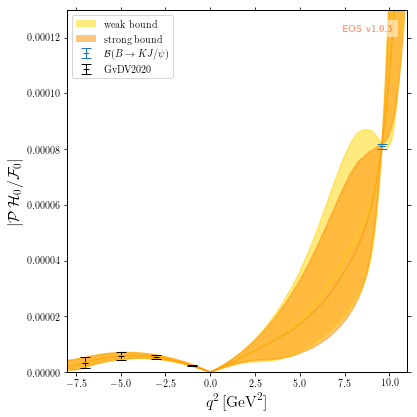

In [110]:
plot_abs_P_ratio_args = {
    'plot': {
        'x': { 'label': r'$q^2$', 'unit': r'$\textnormal{GeV}^2$',  'range': [-8, 11.] },
        'y': { 'label': r'$|\mathcal{P}\,\mathcal{H}_0/\mathcal{F}_0|$', 'range': [0,  1.3e-4]},
        'legend': { 'location': 'upper left' },
        'size': (15,15)
    },
    'contents': [
        {
            'label': r'weak bound',
            'type': 'uncertainty',
            'samples': 500,
            'color': 'gold',
            'range': [-8, 11.],
            'data': { 'samples': observable_samples, 'xvalues': q2values, 'weights': w_bounded_weights }
        },
#        {
#            'label': r'$0$, weak bound',
#            'type': 'uncertainty',
#            'samples': 500,
#            'color': 'C2',
#            'range': [-8, 11.],
#            'data': { 'samples': observable_samples, 'xvalues': q2values, 'weights': w_bounded_weights }
#        },
        {
            'label': r'strong bound',
            'type': 'uncertainty',
            'samples': 500,
            'color': 'darkorange',
            'range': [-8, 11.],
            'data': { 'samples': observable_samples, 'xvalues': q2values, 'weights': s_bounded_weights }
        },
        {
            'label': r'$\mathcal{B}(B\to K J/\psi)$',
            'type': 'constraint',
            'color': 'C0',
            'constraints': 'B->K::abs_P_ratio_plus_fromBdToKdJpsiBR',
            'observable': 'B->K::abs_P_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': r'GvDV2020',
            'type': 'constraint',
            'color': 'k',
            'constraints': 'B->K::abs_P_ratio_plus7',
            'observable': 'B->K::abs_P_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'k',
            'constraints': 'B->K::abs_P_ratio_plus5',
            'observable': 'B->K::abs_P_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'k',
            'constraints': 'B->K::abs_P_ratio_plus3',
            'observable': 'B->K::abs_P_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
        {
            'label': None,
            'type': 'constraint',
            'color': 'k',
            'constraints': 'B->K::abs_P_ratio_plus1',
            'observable': 'B->K::abs_P_ratio_plus(q2)',
            'variable': 'q2',
            'rescale-by-width': False
        },
    ]
}
eos.plot.Plotter(plot_abs_P_ratio_args, "BToK_nlFF.pdf").plot()

mean = 8.192074872903582e-05 ; std = 8.708662594431919e-07


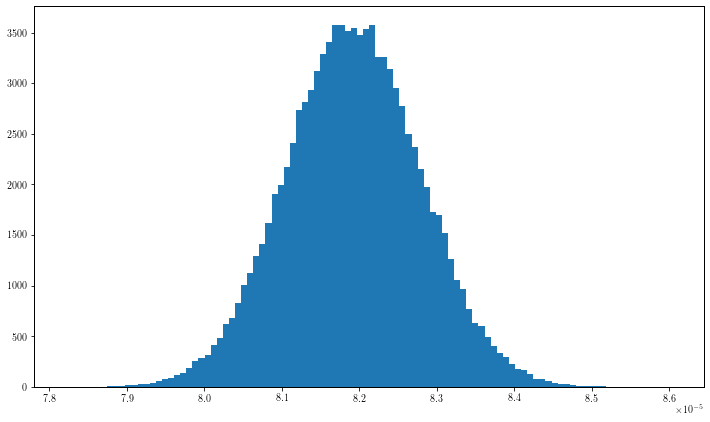

In [111]:
plt.hist(observable_samples[:,462], bins=100)
print(f"mean = {np.mean(observable_samples[:,462])} ; std = {np.std(observable_samples[:,462])}")
plt.show()